In [2]:
!pip -q install imbalanced-learn xgboost openpyxl

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import seaborn as sns

In [4]:
OUTPUT_DIR = "paper_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [5]:
if os.path.exists("/content/CreditCardData.csv"):
    file_path = "/content/CreditCardData.csv"
else:
    print("Please upload your CreditCardData.csv file:")
    uploaded = files.upload()

    uploaded_name = list(uploaded.keys())[0]
    file_path = "/content/" + uploaded_name


df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

DATASET LOADED SUCCESSFULLY
Dataset Shape: (100000, 16)

Columns:
['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud']

First 5 Rows:


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [6]:
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFraud Class Distribution:")
print(df["Fraud"].value_counts())

print("\nFraud Percentage:")
print(df["Fraud"].value_counts(normalize=True) * 100)


DATASET INFORMATION

Missing Values:
Transaction ID             0
Date                       0
Day of Week                0
Time                       0
Type of Card               0
Entry Mode                 0
Amount                     6
Type of Transaction        0
Merchant Group            10
Country of Transaction     0
Shipping Address           5
Country of Residence       0
Gender                     4
Age                        0
Bank                       0
Fraud                      0
dtype: int64

Fraud Class Distribution:
Fraud
0    92805
1     7195
Name: count, dtype: int64

Fraud Percentage:
Fraud
0    92.805
1     7.195
Name: proportion, dtype: float64


In [7]:
data = df.copy()

# ------------------------------------------------------------
# Remove Transaction ID
# ------------------------------------------------------------

if "Transaction ID" in data.columns:
    data = data.drop(columns=["Transaction ID"])


# ------------------------------------------------------------
# Convert Amount
# Remove £ symbol and convert to numeric
# ------------------------------------------------------------

if "Amount" in data.columns:

    data["Amount"] = (
        data["Amount"]
        .astype(str)
        .str.replace("£", "", regex=False)
        .str.replace(",", "", regex=False)
    )

    data["Amount"] = pd.to_numeric(
        data["Amount"],
        errors="coerce"
    )


# ------------------------------------------------------------
# Convert Date
# Create Day, Month and Year features
# ------------------------------------------------------------

if "Date" in data.columns:

    data["Date"] = pd.to_datetime(
        data["Date"],
        format="%d-%b-%y",
        errors="coerce"
    )

    data["Date_Day"] = data["Date"].dt.day
    data["Date_Month"] = data["Date"].dt.month
    data["Date_Year"] = data["Date"].dt.year

    data = data.drop(columns=["Date"])

In [8]:
X = data.drop(columns=["Fraud"])
y = data["Fraud"]

In [9]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("\n" + "=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)
print(numeric_features)

print("\n" + "=" * 70)
print("CATEGORICAL FEATURES")
print("=" * 70)
print(categorical_features)


NUMERICAL FEATURES
['Time', 'Amount', 'Age']

CATEGORICAL FEATURES
['Day of Week', 'Type of Card', 'Entry Mode', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Bank']


In [10]:
# Numerical:
# - Missing values filled using median
# - StandardScaler

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# Categorical:
# - Missing values filled using most frequent value
# - One Hot Encoding

try:

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

except TypeError:

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse=False
                )
            )
        ]
    )


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 10. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================
#
# Paper:
# 70% Training
# 15% Validation
# 15% Testing
#
# First:
# 70% train
# 30% temporary
#
# Then temporary:
# 50% validation
# 50% test
#
# Final:
# 70 / 15 / 15
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp
)


print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

print("Training samples   :", len(X_train))
print("Validation samples :", len(X_val))
print("Testing samples    :", len(X_test))


DATA SPLIT
Training samples   : 70000
Validation samples : 15000
Testing samples    : 15000


In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)


print("\nProcessed Training Shape:", X_train_processed.shape)
print("Processed Validation Shape:", X_val_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)



Processed Training Shape: (70000, 50)
Processed Validation Shape: (15000, 50)
Processed Test Shape: (15000, 50)


In [12]:
SMOTE_K = 3
SMOTE_RATIO = 0.03

train_counts = pd.Series(y_train).value_counts()

majority_count = train_counts[0]
minority_count = train_counts[1]

current_ratio = minority_count / majority_count

print("\n" + "=" * 70)
print("SMOTE")
print("=" * 70)

print("Paper SMOTE k              :", SMOTE_K)
print("Paper SMOTE sampling ratio :", SMOTE_RATIO)
print("Current minority/majority ratio:", current_ratio)


if SMOTE_RATIO > current_ratio:

    smote = SMOTE(
        sampling_strategy=SMOTE_RATIO,
        k_neighbors=SMOTE_K
    )

    X_train_balanced, y_train_balanced = smote.fit_resample(
        X_train_processed,
        y_train
    )

    print("SMOTE applied successfully.")

else:

    X_train_balanced = X_train_processed.copy()
    y_train_balanced = y_train.copy()

    print(
        "\nSMOTE was not applied because sampling_strategy=0.03 "
        "is lower than the existing minority/majority ratio."
    )

    print(
        "The paper's stated value 0.03 has been preserved."
    )


print("\nTraining distribution after SMOTE step:")
print(pd.Series(y_train_balanced).value_counts())


SMOTE
Paper SMOTE k              : 3
Paper SMOTE sampling ratio : 0.03
Current minority/majority ratio: 0.07753644382186783

SMOTE was not applied because sampling_strategy=0.03 is lower than the existing minority/majority ratio.
The paper's stated value 0.03 has been preserved.

Training distribution after SMOTE step:
Fraud
0    64963
1     5037
Name: count, dtype: int64


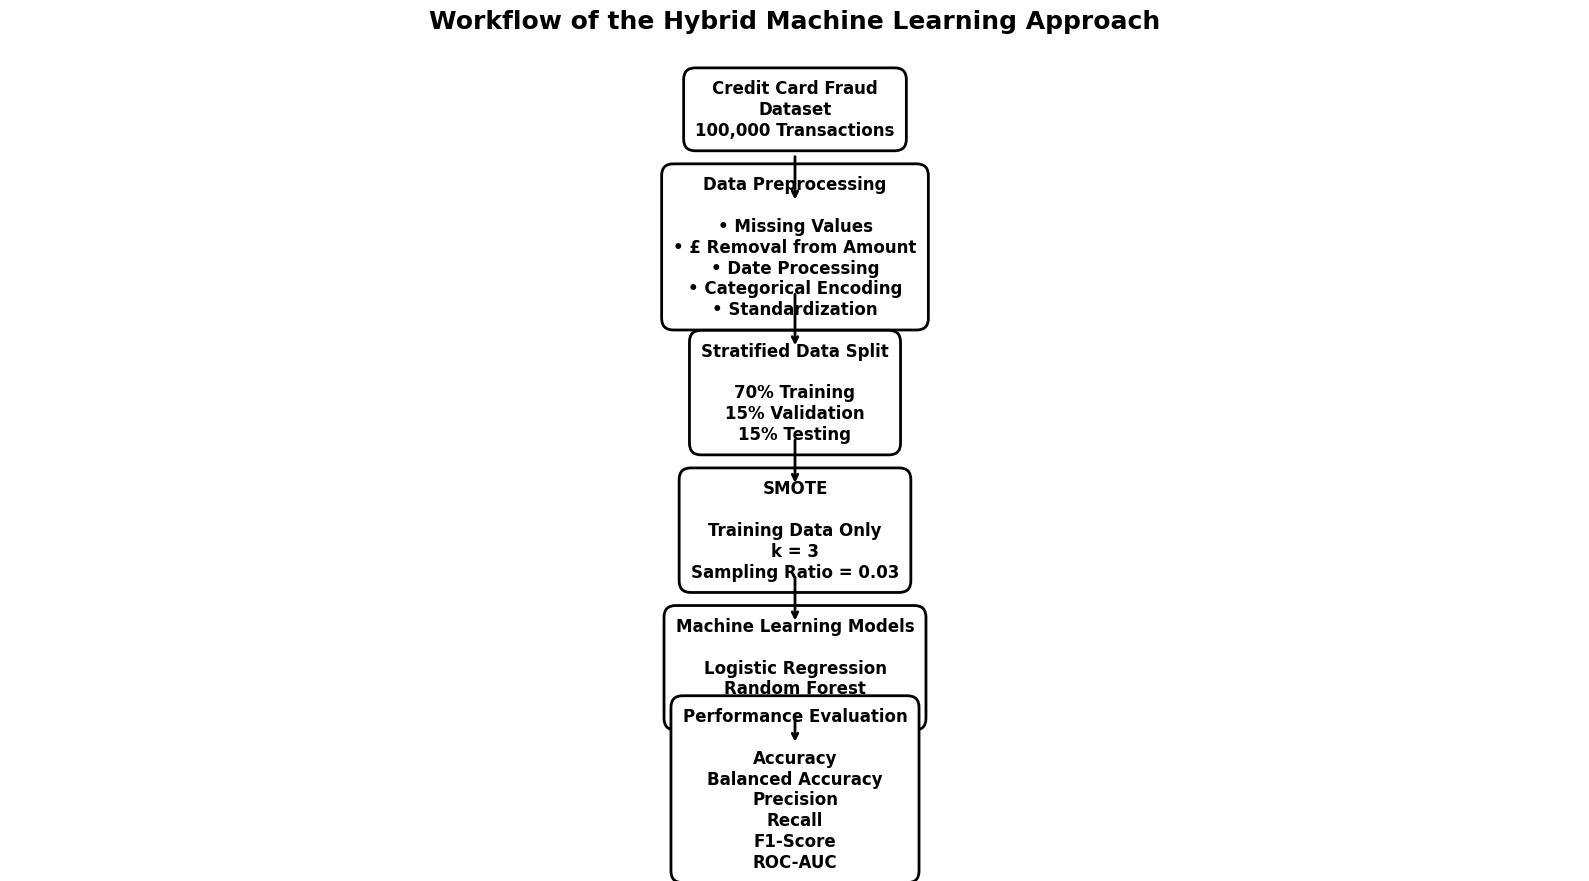

In [13]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.axis("off")

boxes = [
    ("Credit Card Fraud\nDataset\n100,000 Transactions", 0.50, 0.91),
    ("Data Preprocessing\n\n• Missing Values\n• £ Removal from Amount\n• Date Processing\n• Categorical Encoding\n• Standardization", 0.50, 0.74),
    ("Stratified Data Split\n\n70% Training\n15% Validation\n15% Testing", 0.50, 0.56),
    ("SMOTE\n\nTraining Data Only\nk = 3\nSampling Ratio = 0.03", 0.50, 0.39),
    ("Machine Learning Models\n\nLogistic Regression\nRandom Forest\nXGBoost", 0.50, 0.22),
    ("Performance Evaluation\n\nAccuracy\nBalanced Accuracy\nPrecision\nRecall\nF1-Score\nROC-AUC", 0.50, 0.07)
]

for text, x, y_pos in boxes:

    ax.text(
        x,
        y_pos,
        text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.7",
            facecolor="white",
            edgecolor="black",
            linewidth=2
        )
    )


for i in range(len(boxes) - 1):

    y1 = boxes[i][2] - 0.055
    y2 = boxes[i + 1][2] + 0.055

    ax.annotate(
        "",
        xy=(0.50, y2),
        xytext=(0.50, y1),
        arrowprops=dict(
            arrowstyle="->",
            lw=2
        )
    )


plt.title(
    "Workflow of the Hybrid Machine Learning Approach",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_1_Workflow_Diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

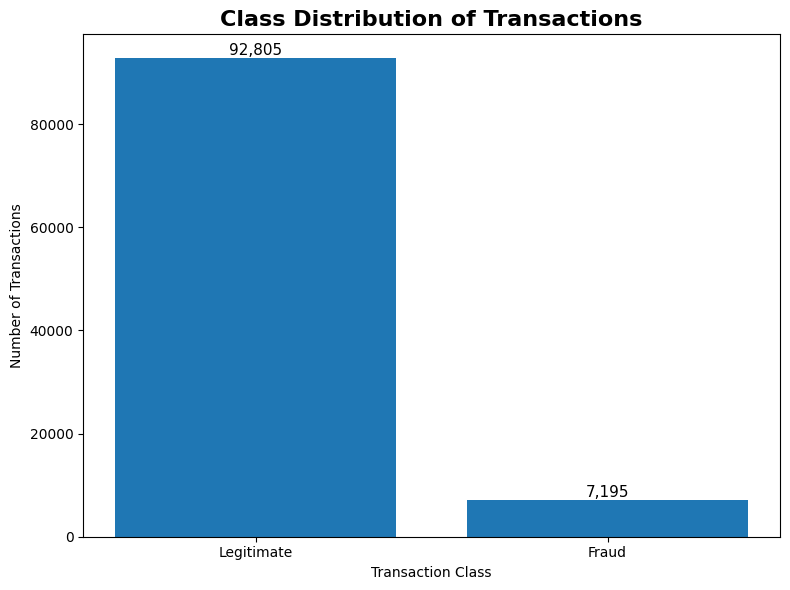

In [14]:
class_counts = df["Fraud"].value_counts().sort_index()

plt.figure(figsize=(8, 6))

bars = plt.bar(
    ["Legitimate", "Fraud"],
    [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
)

plt.title(
    "Class Distribution of Transactions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_2_Class_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
models = {

    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        max_iter=500,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        learning_rate=0.04,
        max_depth=4,
        subsample=0.70,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}

In [16]:
trained_models = {}

results = {}

predictions = {}

probabilities = {}


print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)


for name, model in models.items():

    print("\nTraining:", name)

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    trained_models[name] = model

    y_pred = model.predict(X_test_processed)

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(
            X_test_processed
        )[:, 1]

    else:

        y_prob = model.decision_function(
            X_test_processed
        )


    predictions[name] = y_pred

    probabilities[name] = y_prob


    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )


    results[name] = {

        "Accuracy": accuracy,

        "Balanced Accuracy":
            balanced_accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1": f1,

        "ROC-AUC":
            roc_auc
    }


    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Legitimate",
                "Fraud"
            ],
            zero_division=0
        )
    )


MODEL TRAINING

Training: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96     13921
       Fraud       0.52      0.95      0.67      1079

    accuracy                           0.93     15000
   macro avg       0.76      0.94      0.82     15000
weighted avg       0.96      0.93      0.94     15000


Training: Random Forest

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.93      0.96     13921
       Fraud       0.53      0.97      0.69      1079

    accuracy                           0.94     15000
   macro avg       0.76      0.95      0.83     15000
weighted avg       0.96      0.94      0.94     15000


Training: XGBoost

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     13921
       Fraud       0.99      0.84      0.91      1079

    accuracy       

In [17]:
results_df = pd.DataFrame(results).T

print("\n" + "=" * 70)
print("TEST SET PERFORMANCE")
print("=" * 70)

display(
    results_df.round(4)
)


TEST SET PERFORMANCE


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9341,0.9418,0.5229,0.9509,0.6748,0.9839
Random Forest,0.9362,0.9519,0.5309,0.9703,0.6863,0.9930
XGBoost,0.9877,0.9190,0.9880,0.8387,0.9073,0.9946


In [18]:
paper_results = pd.DataFrame({

    "Accuracy": [
        0.938,
        0.947,
        0.979
    ],

    "Balanced Accuracy": [
        0.943,
        0.949,
        0.931
    ],

    "Precision": [
        0.540,
        0.581,
        0.840
    ],

    "Recall": [
        0.948,
        0.952,
        0.874
    ],

    "F1": [
        0.688,
        0.722,
        0.856
    ],

    "ROC-AUC": [
        0.985,
        0.993,
        0.994
    ]

}, index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])


print("\n" + "=" * 70)
print("PAPER-REPORTED TEST RESULTS")
print("=" * 70)

display(
    paper_results.round(3)
)


PAPER-REPORTED TEST RESULTS


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.938,0.943,0.540,0.948,0.688,0.985
Random Forest,0.947,0.949,0.581,0.952,0.722,0.993
XGBoost,0.979,0.931,0.840,0.874,0.856,0.994


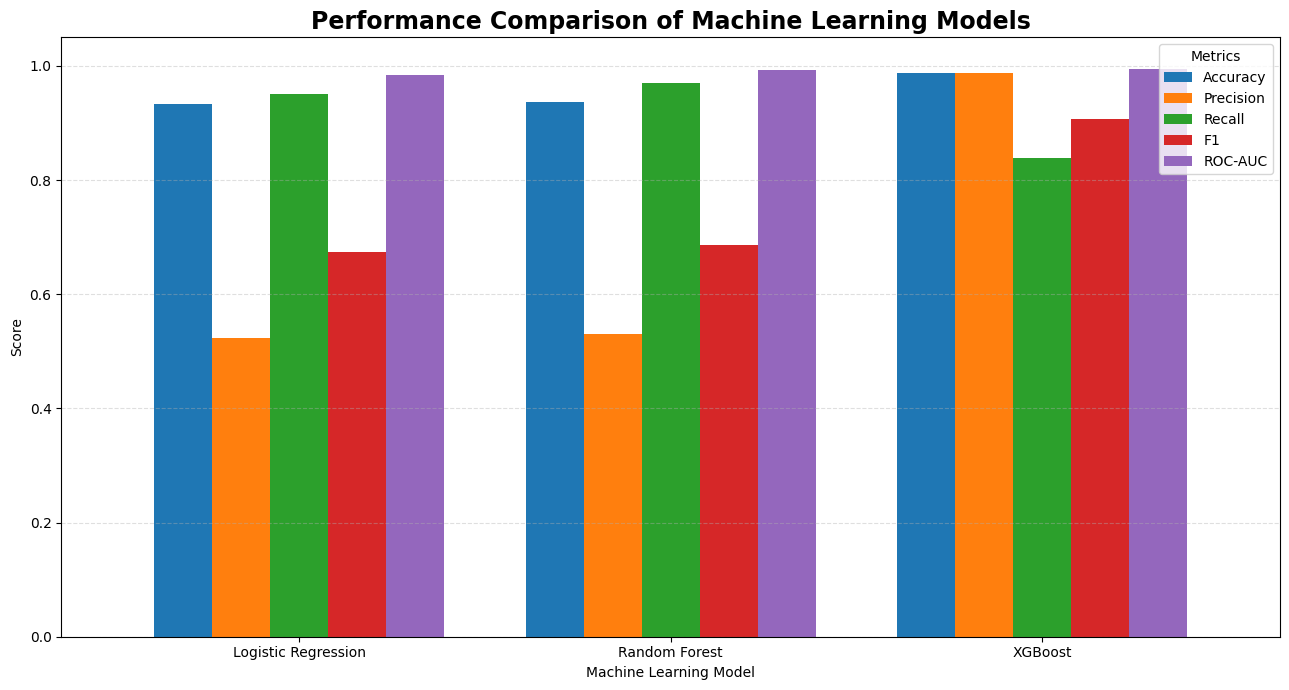

In [19]:
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

plot_df = results_df[
    metrics_to_plot
]


ax = plot_df.plot(
    kind="bar",
    figsize=(13, 7),
    width=0.78
)

plt.title(
    "Performance Comparison of Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metrics"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_3_Model_Metric_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

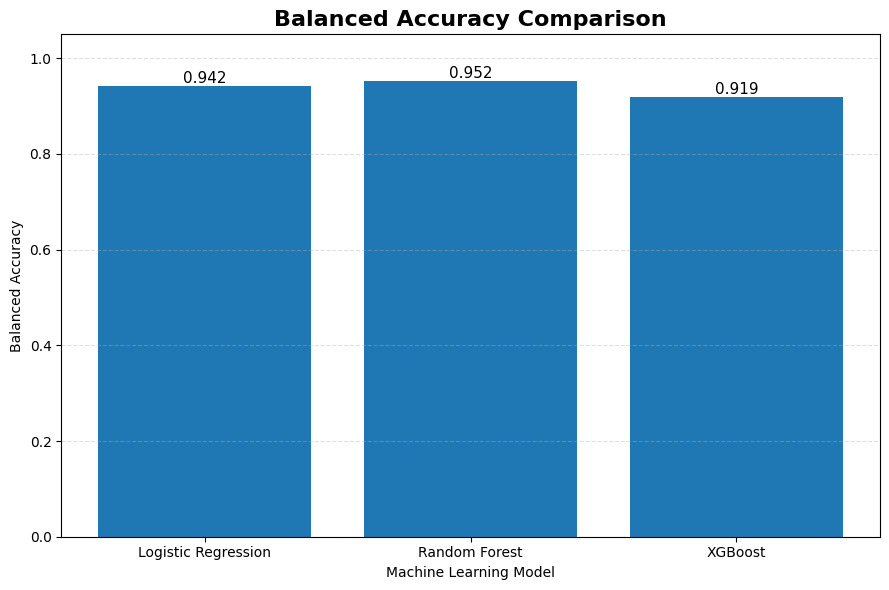

In [20]:
plt.figure(figsize=(9, 6))

bars = plt.bar(
    results_df.index,
    results_df["Balanced Accuracy"]
)

plt.title(
    "Balanced Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Balanced Accuracy")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_4_Balanced_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

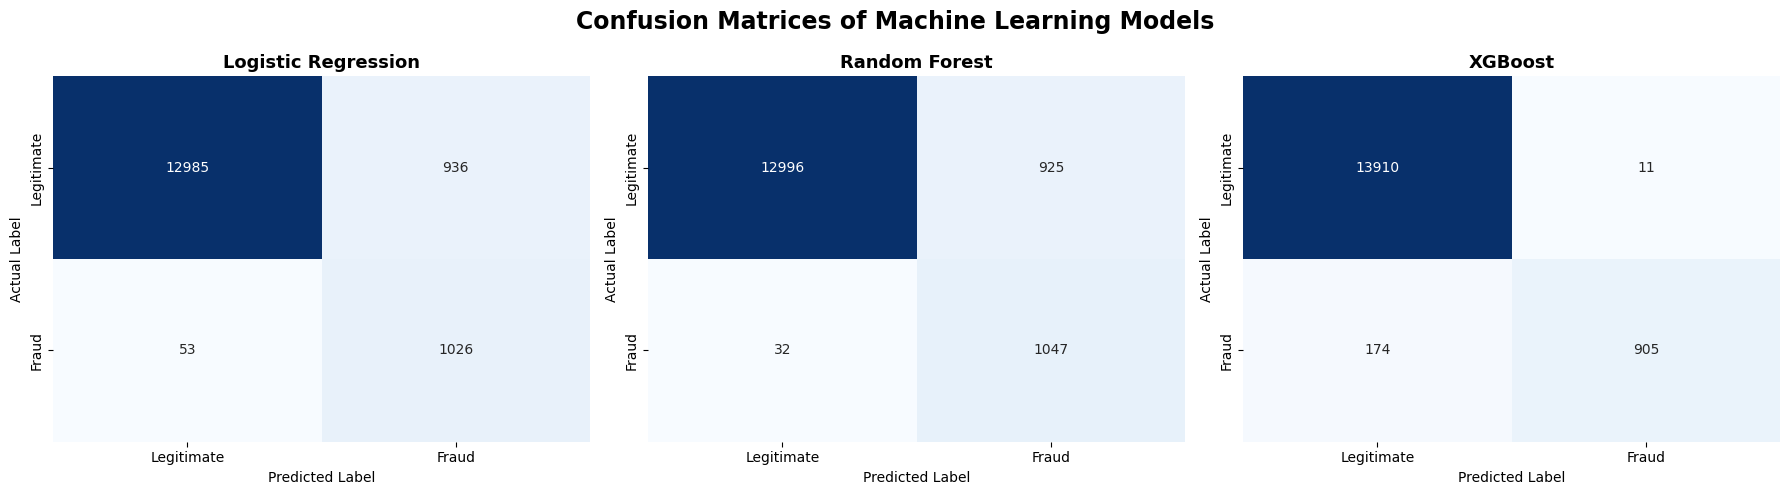

In [21]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, name in zip(
    axes,
    trained_models.keys()
):

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=[
            "Legitimate",
            "Fraud"
        ],
        yticklabels=[
            "Legitimate",
            "Fraud"
        ]
    )

    ax.set_title(
        name,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Predicted Label"
    )

    ax.set_ylabel(
        "Actual Label"
    )


plt.suptitle(
    "Confusion Matrices of Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_5_Confusion_Matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

for name in trained_models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    print("\n", name)

    print(
        "TN =", cm[0, 0],
        "| FP =", cm[0, 1]
    )

    print(
        "FN =", cm[1, 0],
        "| TP =", cm[1, 1]
    )


CONFUSION MATRICES

 Logistic Regression
TN = 12985 | FP = 936
FN = 53 | TP = 1026

 Random Forest
TN = 12996 | FP = 925
FN = 32 | TP = 1047

 XGBoost
TN = 13910 | FP = 11
FN = 174 | TP = 905


In [23]:
paper_cm = {

    "Logistic Regression":
        [[13051, 870],
         [56, 1023]],

    "Random Forest":
        [[13181, 740],
         [52, 1027]],

    "XGBoost":
        [[13741, 180],
         [136, 943]]
}


print("\n" + "=" * 70)
print("PAPER-REPORTED CONFUSION MATRICES")
print("=" * 70)

for name, cm in paper_cm.items():

    print("\n", name)

    print(
        "TN =", cm[0][0],
        "| FP =", cm[0][1]
    )

    print(
        "FN =", cm[1][0],
        "| TP =", cm[1][1]
    )


PAPER-REPORTED CONFUSION MATRICES

 Logistic Regression
TN = 13051 | FP = 870
FN = 56 | TP = 1023

 Random Forest
TN = 13181 | FP = 740
FN = 52 | TP = 1027

 XGBoost
TN = 13741 | FP = 180
FN = 136 | TP = 943


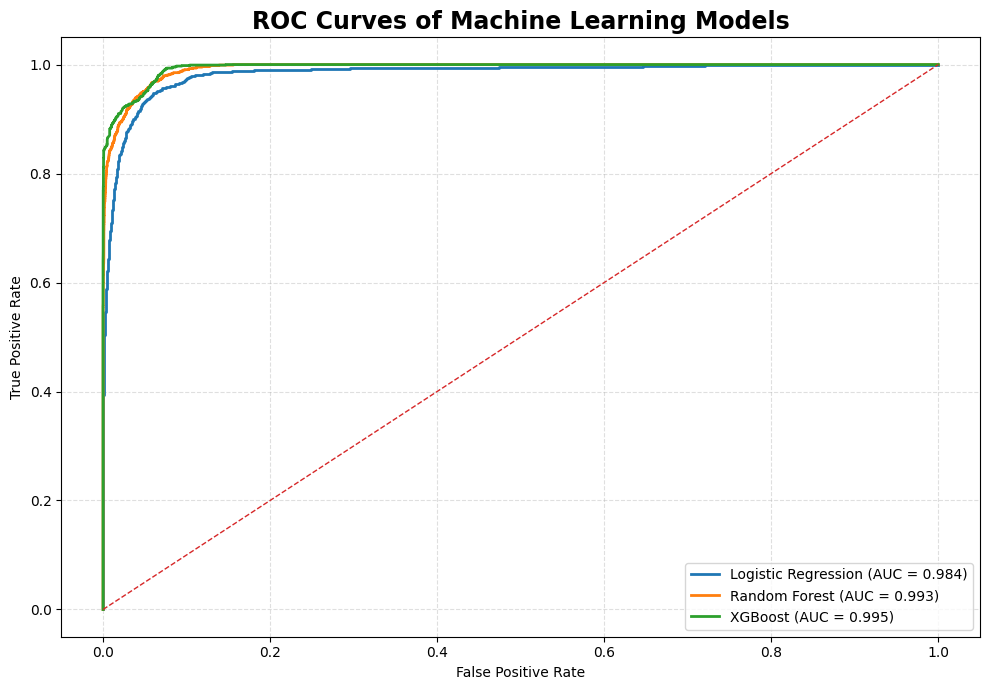

In [24]:
plt.figure(figsize=(10, 7))

for name in trained_models.keys():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.title(
    "ROC Curves of Machine Learning Models",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_6_ROC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Convert original test Amount to numeric

test_amount = (
    X_test["Amount"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace(",", "", regex=False)
)

test_amount = pd.to_numeric(
    test_amount,
    errors="coerce"
)

test_amount = test_amount.fillna(
    test_amount.median()
)

test_amount_array = test_amount.values


financial_results = {}


for name in trained_models.keys():

    y_pred = predictions[name]

    actual_fraud = (
        y_test.values == 1
    )

    detected_fraud = (
        (y_test.values == 1) &
        (y_pred == 1)
    )

    missed_fraud = (
        (y_test.values == 1) &
        (y_pred == 0)
    )


    total_actual_amount = (
        test_amount_array[actual_fraud].sum()
    )

    detected_amount = (
        test_amount_array[detected_fraud].sum()
    )

    missed_amount = (
        test_amount_array[missed_fraud].sum()
    )


    captured_percentage = (

        detected_amount /
        total_actual_amount *
        100

        if total_actual_amount > 0
        else 0
    )


    financial_results[name] = {

        "Total Actual Fraud Amount":
            total_actual_amount,

        "Detected Fraud Amount":
            detected_amount,

        "Missed Fraud Amount":
            missed_amount,

        "Fraud Amount Captured (%)":
            captured_percentage
    }


financial_df = pd.DataFrame(
    financial_results
).T


print("\n" + "=" * 70)
print("FINANCIAL IMPACT")
print("=" * 70)

display(
    financial_df.round(2)
)


FINANCIAL IMPACT


,Total Actual Fraud Amount,Detected Fraud Amount,Missed Fraud Amount,Fraud Amount Captured (%)
Logistic Regression,64933.0,60981.0,3952.0,93.91
Random Forest,64933.0,63117.0,1816.0,97.20
XGBoost,64933.0,44046.0,20887.0,67.83


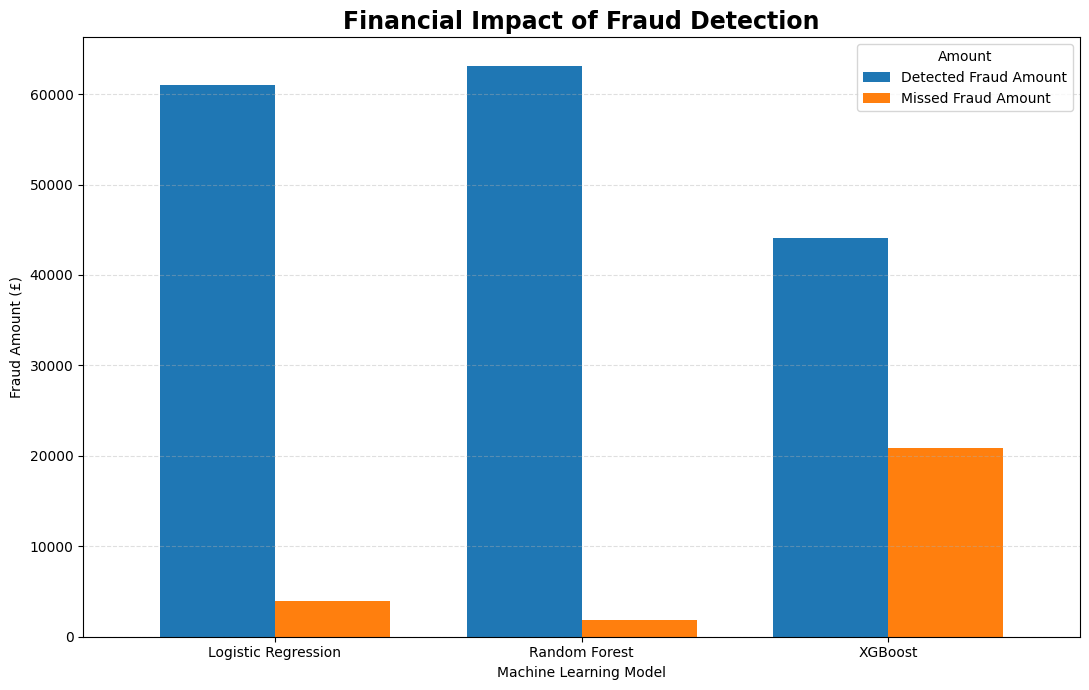

In [26]:
financial_plot = financial_df[
    [
        "Detected Fraud Amount",
        "Missed Fraud Amount"
    ]
]


ax = financial_plot.plot(
    kind="bar",
    figsize=(11, 7),
    width=0.75
)

plt.title(
    "Financial Impact of Fraud Detection",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Fraud Amount (£)"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Amount"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_7_Financial_Impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
paper_financial = pd.DataFrame({

    "Total Actual Fraud Amount": [
        63338,
        63338,
        63338
    ],

    "Detected Fraud Amount": [
        59380,
        60333,
        50294
    ],

    "Missed Fraud Amount": [
        3958,
        3005,
        13044
    ],

    "Fraud Amount Captured (%)": [
        93.75,
        95.26,
        79.41
    ]

}, index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])


print("\n" + "=" * 70)
print("PAPER-REPORTED FINANCIAL RESULTS")
print("=" * 70)

display(
    paper_financial.round(2)
)


PAPER-REPORTED FINANCIAL RESULTS


,Total Actual Fraud Amount,Detected Fraud Amount,Missed Fraud Amount,Fraud Amount Captured (%)
Logistic Regression,63338,59380,3958,93.75
Random Forest,63338,60333,3005,95.26
XGBoost,63338,50294,13044,79.41


In [28]:
xgb_model = trained_models["XGBoost"]


# Get feature names after preprocessing

try:

    feature_names = (
        preprocessor
        .get_feature_names_out()
    )

except:

    feature_names = [
        f"Feature_{i}"
        for i in range(
            len(
                xgb_model.feature_importances_
            )
        )
    ]


importance_values = (
    xgb_model.feature_importances_
)


feature_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        importance_values

})


feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

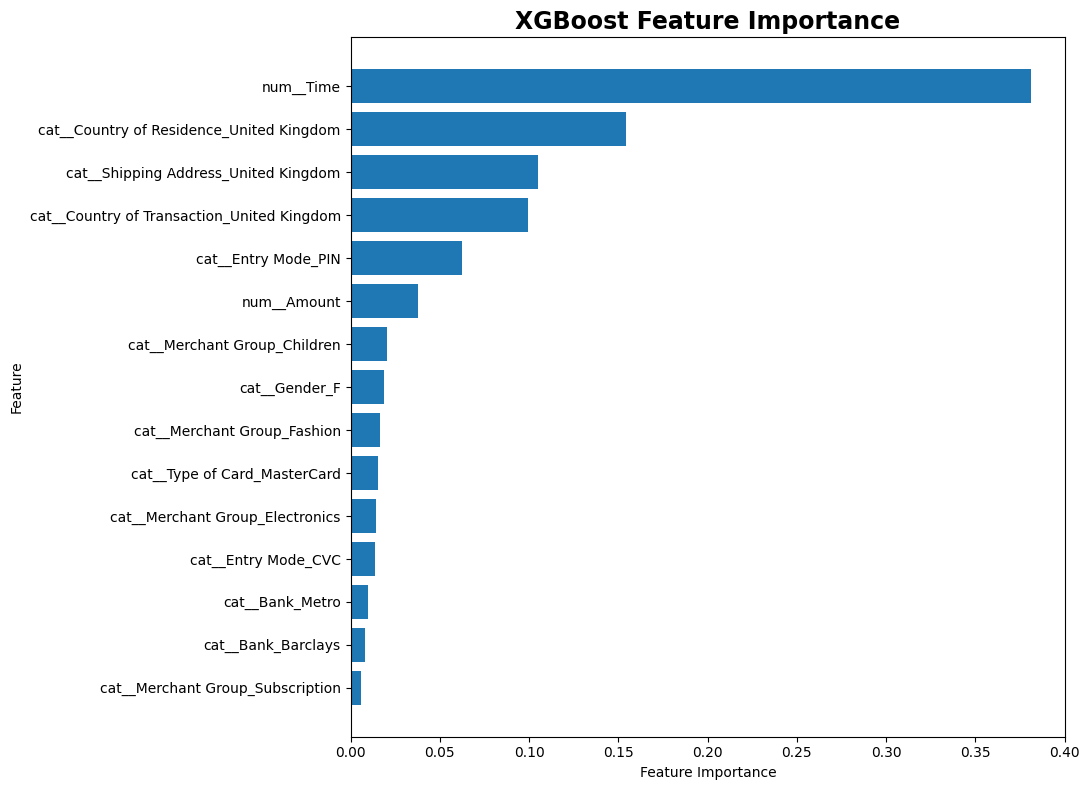

In [29]:
TOP_N = 15

top_features = (
    feature_importance_df
    .head(TOP_N)
    .sort_values(
        by="Importance",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 8)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/Figure_8_XGBoost_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
print("\n" + "=" * 70)
print("TOP XGBOOST FEATURES")
print("=" * 70)

display(
    feature_importance_df
    .head(20)
    .round(6)
)


TOP XGBOOST FEATURES


,Feature,Importance
0,num__Time,0.381166
39,cat__Country of Residence_United Kingdom,0.154124
34,cat__Shipping Address_United Kingdom,0.105253
29,cat__Country of Transaction_United Kingdom,0.099234
10,cat__Entry Mode_PIN,0.062267
1,num__Amount,0.037664
15,cat__Merchant Group_Children,0.020416
40,cat__Gender_F,0.019017
18,cat__Merchant Group_Fashion,0.016573
7,cat__Type of Card_MasterCard,0.015613


In [31]:
results_df.to_csv(
    f"{OUTPUT_DIR}/Model_Performance_Results.csv"
)

financial_df.to_csv(
    f"{OUTPUT_DIR}/Financial_Impact_Results.csv"
)

feature_importance_df.to_csv(
    f"{OUTPUT_DIR}/XGBoost_Feature_Importance.csv",
    index=False
)

In [32]:
print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(
    results_df.round(4)
)


FINAL MODEL PERFORMANCE


,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9341,0.9418,0.5229,0.9509,0.6748,0.9839
Random Forest,0.9362,0.9519,0.5309,0.9703,0.6863,0.9930
XGBoost,0.9877,0.9190,0.9880,0.8387,0.9073,0.9946
